In [21]:
from typing import Annotated
from dotenv import load_dotenv

load_dotenv()
from typing_extensions import TypedDict
from langchain.chat_models import init_chat_model
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END


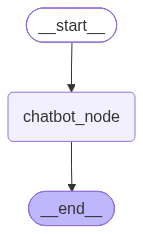

In [29]:
llm = init_chat_model("gemini-3.6-flash", model_provider="google_genai")
# llm.invoke("Who is PM of India?")
class State(TypedDict):
    messages : Annotated[list, add_messages]

def chatbot(state: State) -> State:
    return { "messages" : [llm.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("chatbot_node", chatbot)
builder.add_edge(START, "chatbot_node")
builder.add_edge("chatbot_node", END)

graph = builder.compile()
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [26]:
message = {"role" : "user", "content" : "who is the PM of india? Print only the name"}
response = graph.invoke({"messages" : [message]})

response["messages"]

[HumanMessage(content='who is the PM of india? Print only the name', additional_kwargs={}, response_metadata={}, id='4bd7ac1f-3622-47bb-8b4a-c51a94ed7590'),
 AIMessage(content=[{'type': 'text', 'text': 'Narendra Modi', 'extras': {'signature': 'EvkCCvYCARFNMg9DY+gK+jUKOMJ2vU3iwYPExtVBOCD1jqQ/QREXHyHp22Es3O+YbLMIOFNVYa+aD+9mDJ0gt0eNWzLyLlWGU0UoQ/howxJTET4ORzWtMOoz4Nlvk2wG6a8ls34zJr6vlSoTU0Lxd/7v0qHajEht9+PNQkm25BZAH7k6zSPz9+B0Fl7TSLHIcmo+MdtEnGxnzaHPX/TcBYNfs8oiM6S+uJ90fgCsIs/+WHx1SRH7pTmXaSO/volQCpeCC12WW548kjLwYzAQga3lOKMsSL+ftIKfV8F62DzBWQ+7oyd586dGasyogCmWhoUvnn8i5c0532m49RqLRwaJg1BUGR46ppBGU8VMXsrWBJsgdnuX9FPm6Q0Ya4qXrI0eo+JaPKH85n6KKe4tCtsSenx1XBPz1hCf7PRxERMvGdLhVwGW8HTBCWVL6Ud2hCjvPul1+2YZYXpPLUckInXLqlJTEpgbP1yG7UFoEblA+6xvdiv2pv9GixI='}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.6-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019feac7-5b21-7f21-9e56-f8d0635e2764-0', tool_calls=[], invalid_tool_call

In [31]:
state = None
while True:
    in_message = input("You: ")
    if in_message.lower() in {"quit", "exit"}:
        break
    if state is None:
        state: State = {

            "messages" : [{"role": "user", "content": in_message}]
        }
    else:
        state["messages"].append({"role": "user", "content": in_message})

    state = graph.invoke(state)
    print("Bot:", state["messages"][-1].content)

Bot: [{'type': 'text', 'text': 'Because **Vinayak Ojha** is a name shared by several individuals across different fields, he could refer to a few different people depending on the context:\n\n1. **Tech & Startup / Engineering:** Vinayak Ojha is a name associated with professionals in the Indian technology ecosystem, including software engineers, AI/tech enthusiasts, and startup founders active on platforms like LinkedIn and X (Twitter).\n2. **Academia / Student Achievement:** The name appears in Indian academic records, competitive exam rank lists (such as JEE or UPSC), and research publications.\n3. **Media or Regional Public Life:** There are individuals by this name involved in journalism, local politics, or social activism in various parts of India.\n\n***\n\n**To give you the exact information you are looking for, could you share a bit more context?** \n*(For example: Is he a tech founder, an author, a journalist, a corporate executive, or someone associated with a specific compan